Loading information from: /teamspace/studios/this_studio/phdResearch/data12/Labels/labels.csv
Contain 132 Subjects

EEG CLASSIFICATION PIPELINE
Mode: Train-Test Split (No Validation)
Configuration:
--------------------------------------------------------------------------------
  Dataset path:      /teamspace/studios/this_studio/phdResearch/data12/
  Device:            cuda
  Model choice:      0
  Fold strategy:     manual132
  Number of folds:   5
  Validation split:  None
  Early stopping:    Disabled

Stratification: on (['Group'])

Data Settings:
  Class names:       ['HC', 'AD']
  Normalization:     winsor_zscore
  Norm level:        per_channel

Training Settings:
  Batch size:        16
  Learning rate:     0.0001
  Max epochs:        30

Evaluation Settings:
  Aggregation mode:  majority
  Confidence filter: 0.7
  Save models:       True

Output directory: /teamspace/studios/this_studio/phdResearch/experiment/Combined/results/testtestnew

Get dataset...
Preparing split data..


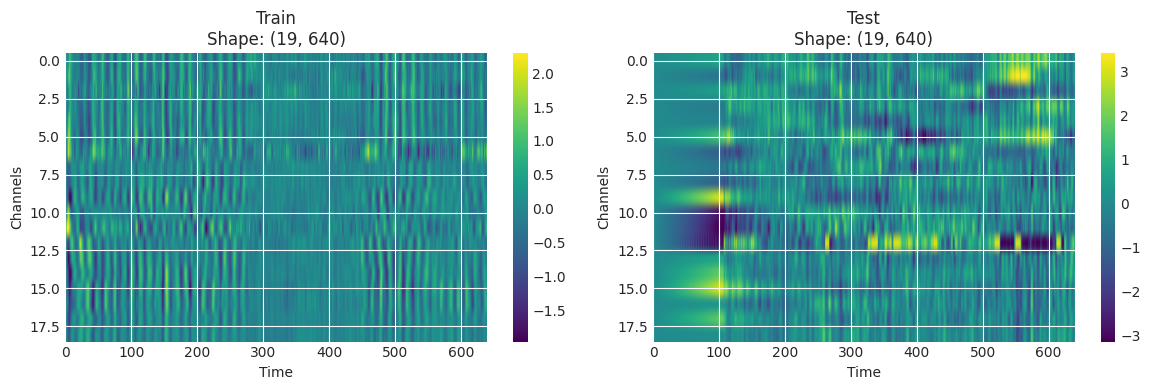


Starting 5-fold cross-validation

Processing Fold 1

Preparing Data for Fold 1
  Segments per subject: All
  Normalization:        winsor_zscore
  Norm level:           per_channel

Loading Train data:
────────────────────────────────────────────────────────────
Sub_105:   65 segments (class 0)
Sub_021:  184 segments (class 1)
Sub_048:  202 segments (class 0)
Sub_042:  195 segments (class 0)
Sub_010:  258 segments (class 1)
Sub_099:  116 segments (class 1)
Sub_014:  189 segments (class 1)
Sub_126:  114 segments (class 0)
Sub_075:   49 segments (class 1)
Sub_096:   99 segments (class 1)
Sub_024:  153 segments (class 1)
Sub_103:   72 segments (class 0)
Sub_038:  178 segments (class 0)
Sub_074:   32 segments (class 1)
Sub_043:  165 segments (class 0)
Sub_066:   62 segments (class 1)
Sub_032:  170 segments (class 1)
Sub_029:  148 segments (class 1)
Sub_106:   89 segments (class 0)
Sub_027:  166 segments (class 1)
Sub_128:  118 segments (class 0)
Sub_107:   99 segments (class 0)
Sub_108:  

In [1]:
#==================================================
#EEG Classification Pipeline 
#==================================================
import os
import sys
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
sys.path.append("/teamspace/studios/this_studio/phdResearch/Models")
from Visualizeclass import EEGVisualizer   
from ManageDatasetM import ManageDataset
from Trainclass import train_model_with_early_stopping, comprehensive_evaluate_model


# ============================================================================
# CONFIGURATION
# ============================================================================
class EEG():
    def __init__(self):
        from config import config
        self.config = config()
        self.EEGV = EEGVisualizer()
        self.dataset = ManageDataset(self.config)
        sys.path.append(self.config['models_path'])
        self.paths = None
       
        self.train_model_with_early_stopping = train_model_with_early_stopping
        self.comprehensive_evaluate_model = comprehensive_evaluate_model
     
    def set_seed(self, seed):
        """Set random seeds for reproducibility."""
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    def Define_Model(self,choice, n_channels, n_time_points, n_classes, dropout_rate):
    
        if choice == 0:
            from TSCNET import EEGModel 
            
        elif choice == 1:
            from TSCNET1 import EEGModel
            
        elif choice == 2:
            from TSCNET2 import EEGModel
            
        elif choice == 3:
            from TSCNET3 import EEGModel
            
        model = EEGModel(
            channels=n_channels,
            num_classes=n_classes,
            dropout_rate=dropout_rate
            )
        return model 
    
        
    def print_config(self):
        
        print("\n" + "=" * 80)
        print("EEG CLASSIFICATION PIPELINE")
        if self.config['val_split'] > 0:
            print("Mode: Train-Validation-Test Split with Early Stopping")
        else:
            print("Mode: Train-Test Split (No Validation)")
        print("=" * 80)
        
        print("Configuration:")
        print("-" * 80)
        print(f"  Dataset path:      { self.config['dataset_path']}")
        print(f"  Device:            { self.config['device']}")
        print(f"  Model choice:      { self.config['model_choice']}")
        print(f"  Fold strategy:     { self.config['fold_strategy']}")
        print(f"  Number of folds:   { self.config['k_folds']}")
        
        if self.config['val_split'] > 0:
            print(f"  Validation split:  {self.config['val_split']*100:.0f}%")
            print(f"  Early stopping:    Enabled (patience={self.config['params']['patience']})")
        else:
            print(f"  Validation split:  None")
            print(f"  Early stopping:    Disabled")
        
        print(f"\nStratification: on ({self.config['stratify_columns']})")
        
        print(f"\nData Settings:")
        print(f"  Class names:       {self.config['class_names']}")
        print(f"  Normalization:     {self.config['normalization']}")
        print(f"  Norm level:        {self.config['norm_level']}")
        
        print(f"\nTraining Settings:")
        print(f"  Batch size:        {self.config['params']['batch_size']}")
        print(f"  Learning rate:     {self.config['params']['learning_rate']}")
        print(f"  Max epochs:        {self.config['params']['epochs']}")
        
        
        print(f"\nEvaluation Settings:")
        print(f"  Aggregation mode:  {self.config['evaluation']['aggregation_mode']}")
        print(f"  Confidence filter: {self.config['evaluation']['confidence_filter']}")
        print(f"  Save models:       {self.config['save_models']}")
        print("=" * 80) 
    ######################################################################################
    
    def setup_output_directory(self):
        from datetime import datetime
        
        if self.config['experiment_name'] is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            exp_name = timestamp
        else:
            exp_name = self.config['experiment_name']
        
        # Create directory structure
        base_dir = Path(self.config['output_dir']) / exp_name
        self.paths = {
            'base': base_dir,
            'models': base_dir / 'models',
            'plots': base_dir / 'plots',
            'results': base_dir / 'results',
           
        }
        
        for path in self.paths.values():
            path.mkdir(parents=True, exist_ok=True)
        print(f"\nOutput directory: {base_dir}")
        
    ######################################################################################
    def clear_memory(self):
        """Clean up memory and GPU cache."""
        plt.close('all')
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    ######################################################################################
    def run_single_fold(self,fold_config):
        
        fold_num = fold_config['fold_num']
        print(f"\n{'='*80}")
        print(f"Processing Fold {fold_num}")
        print(f"{'='*80}")
        
        try:
            self.clear_memory()
            
            # Prepare data - returns (train_set, val_set, test_set)
            fold_data = self.dataset.prepare_fold_data(
                fold_config, 
                segments_per_subject = self.config['segments_per_subject'],
                normalization = self.config['normalization'],
                norm_level = self.config['norm_level']
            )
            
            # -----------------------------
            # Unpack train / val / test sets
            # -----------------------------
            train_set = fold_data[0]       # (train_data, train_labels)
            val_set   = fold_data[1]       # (val_data, val_labels) or (None, None)
            test_fold = fold_data[2]       # (test_data, test_labels, [test_subject_ids])
            
            # Handle test set (2-tuple or 3-tuple)
            if len(test_fold) == 3:
                test_data, test_labels, test_subject_ids = test_fold
            else:
                test_data, test_labels = test_fold
                test_subject_ids = None
            
            # Determine validation presence
            has_validation = val_set[0] is not None
            
            print(f"\nDataset split:")
            print(f"  Train: {train_set[0].shape[0]} samples")
            if has_validation:
                print(f"  Val:   {val_set[0].shape[0]} samples")
            else:
                print(f"  Val:   None (val_split=0)")
            print(f"  Test:  {test_data.shape[0]} samples")
            
            # Create model
            model = self.Define_Model(
                choice=self.config['model_choice'], 
                n_channels = self.config['model_params']['n_channels'], 
                n_time_points = self.config['model_params']['n_time_points'],
                n_classes = self.config['model_params']['n_classes'],
                dropout_rate = self.config['model_params']['dropout_rate']
            )
             # Move model to device
            model = model.to(self.config['device'])
            print(f"\nModel: {model.__class__.__name__}")
           
            print(f"  Device: {self.config['device']}")
            # Count parameters
            total_params = sum(p.numel() for p in model.parameters())
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"Total parameters: {total_params:,}")
            print(f"Trainable parameters: {trainable_params:,}")
            
            # Train model
            if has_validation:
                print("\nTraining with validation set and early stopping...")
                trained_model, history = train_model_with_early_stopping(
                    model, 
                    train_set, 
                    val_set, 
                    self.config['params']['batch_size'], 
                    self.config['params']['epochs'], 
                    self.config['params']['learning_rate'], 
                    self.config['params']['patience'],
                    device = self.config['device']
                )
            else:
                print("\nTraining without validation set (using all epochs)...")
                trained_model, history = self.train_model_with_early_stopping(
                    model, 
                    train_set, 
                    None,  # No validation set
                    self.config['params']['batch_size'], 
                    self.config['params']['epochs'], 
                    self.config['params']['learning_rate'], 
                    patience=None,  # Disable early stopping
                    device=self.config['device']
                )
            
            # Plot training curves
            self.EEGV.plot_training_curves(history, fold_num,self.paths['plots'])
            
            # Plot overfitting analysis only if validation exists
            if has_validation and 'val_loss' in history:
                self.EEGV.plot_overfitting_analysis(history, fold_num,self.paths['plots'])
            else:
                print("Skipping overfitting analysis (no validation set)")
            
            # -----------------------------
            # SUBJECT-LEVEL evaluation hook
            # -----------------------------
            # Prefer IDs coming from fold_data (already unpacked)
            subject_ids = test_subject_ids
            
            # Backward-compatibility: if dataset stores them as attribute
            if subject_ids is None and hasattr(self.dataset, "test_subject_ids"):
                subject_ids = self.dataset.test_subject_ids
            
            # Evaluate (pass a 2-tuple for test_set!)
            test_metrics = self.comprehensive_evaluate_model(
                trained_model,
                (test_data, test_labels),
                ['HC', 'AD'],
                subject_ids= subject_ids, 
                aggregation_mode=self.config['evaluation']['aggregation_mode'],  
                confidence_filter= self.config['evaluation']['confidence_filter'],      
                save_segment_csv=self.paths['results'] / f"segment_predictions.csv",
                device=self.config['device']
            )
    
            # Plot confusion matrix
            self.EEGV.plot_confusion_matrix(
                test_metrics['confusion_matrix'], ['HC', 'AD'], fold_num,self.paths['plots']
            )
            
            # Print fold results
            print(f"\n{'='*80}")
            print(f"Fold {fold_num} Test Results")
            print(f"{'='*80}")
            print(f"  Accuracy:    {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
            print(f"  Sensitivity: {test_metrics['sensitivity']:.4f} ({test_metrics['sensitivity']*100:.2f}%)")
            print(f"  Specificity: {test_metrics['specificity']:.4f} ({test_metrics['specificity']*100:.2f}%)")
            print(f"  ROC AUC:     {test_metrics['roc_auc']:.4f}")
            print(f"  Precision:   {np.mean(test_metrics['precision']):.4f}")
            print(f"  Recall:      {np.mean(test_metrics['recall']):.4f}")
            print(f"  F1-Score:    {np.mean(test_metrics['f1_score']):.4f}")
            print(f"{'='*80}\n")
            torch.save(trained_model.state_dict(),self.paths['models'] / f"fold_{fold_num}.pth")

            # Cleanup
            del model, trained_model, train_set, val_set, test_fold, test_data, test_labels
            self.clear_memory()
            
            return {
                'fold': fold_num,
                'test_metrics': test_metrics,
                'history': history
            }
            
        except Exception as e:
            print(f"\n{'!'*80}")
            print(f"ERROR in fold {fold_num}: {e}")
            print(f"{'!'*80}")
            import traceback
            traceback.print_exc()
            self.clear_memory()
            return None
    ######################################################################################
    def print_final_results(self,all_fold_results):

        if not all_fold_results:
            print(f"\n{'!'*80}")
            print("ERROR: No successful folds completed")
            print(f"{'!'*80}")
            return None
        
        print("\n" + "=" * 80)
        print("FINAL CROSS-VALIDATION RESULTS")
        print("=" * 80)
        
        # ========================================================================
        # 1. PLOT COMPREHENSIVE SUMMARY
        # ========================================================================
        plt.figure()
        self.EEGV.plot_cross_validation_summary(all_fold_results,self.paths['plots'])
        plt.close()
        
        plt.figure()
        self.EEGV.plot_roc_from_folds(all_fold_results,self.paths['plots'])
        plt.close()
        
        # ========================================================================
        # 2. CALCULATE METRICS
        # ========================================================================
        metrics = {}
        
        # Scalar metrics
        for metric_name in ['accuracy', 'roc_auc', 'sensitivity', 'specificity']:
            values = [result['test_metrics'][metric_name] for result in all_fold_results]
            metrics[metric_name] = values
        
        # Array metrics (take mean)
        for metric_name in ['precision', 'recall', 'f1_score']:
            values = [np.mean(result['test_metrics'][metric_name]) for result in all_fold_results]
            metrics[metric_name] = values
        
        # ========================================================================
        # 3. PRINT SUMMARY STATISTICS
        # ========================================================================
        print("\nPerformance Summary (Mean ± Std):")
        print("-" * 80)
        for metric_name, values in metrics.items():
            mean_val = np.mean(values)
            std_val = np.std(values)
            min_val = np.min(values)
            max_val = np.max(values)
            print(f"  {metric_name.replace('_', ' ').title():15s}: "
                  f"{mean_val:.4f} ± {std_val:.4f} "
                  f"[{min_val:.4f}, {max_val:.4f}]")
        
        # ========================================================================
        # 4. PRINT INDIVIDUAL FOLD RESULTS
        # ========================================================================
        print("\n" + "=" * 80)
        print("Individual Fold Results")
        print("=" * 80)
        print(f"{'Fold':>6s} | {'Accuracy':>8s} | {'F1':>8s} | {'AUC':>8s} | "
              f"{'Sens':>8s} | {'Spec':>8s}")
        print("-" * 80)
        
        for i, result in enumerate(all_fold_results):
            fold_num = result['fold']
            acc = metrics['accuracy'][i]
            f1 = metrics['f1_score'][i]
            auc = metrics['roc_auc'][i]
            sens = metrics['sensitivity'][i]
            spec = metrics['specificity'][i]
            print(f"{fold_num:6d} | {acc:8.4f} | {f1:8.4f} | {auc:8.4f} | "
                  f"{sens:8.4f} | {spec:8.4f}")
        print("=" * 80)
        
        # ========================================================================
        # 5. SAVE RESULTS TO CSV
        # ========================================================================
        results_df = pd.DataFrame({
            'Fold': [result['fold'] for result in all_fold_results],
            **{metric.replace('_', ' ').title(): values 
               for metric, values in metrics.items()}
        })
        
        # Add summary statistics
        summary_row = {'Fold': 'Mean'}
        for metric, values in metrics.items():
            summary_row[metric.replace('_', ' ').title()] = np.mean(values)
        results_df = pd.concat([results_df, pd.DataFrame([summary_row])], ignore_index=True)
        
        summary_row = {'Fold': 'Std'}
        for metric, values in metrics.items():
            summary_row[metric.replace('_', ' ').title()] = np.std(values)
        results_df = pd.concat([results_df, pd.DataFrame([summary_row])], ignore_index=True)
        
        filename = self.paths['results'] / f'cv_results_{self.config["fold_strategy"]}_{self.config["k_folds"]}folds.csv'
        results_df.to_csv(filename, index=False)
        print(f"\nResults saved to: {filename}")
        
        # ========================================================================
        # 6. CALCULATE 95% CONFIDENCE INTERVALS
        # ========================================================================
        print("\n95% Confidence Intervals:")
        print("-" * 80)
        ci_data = []
        for metric_name, values in metrics.items():
            mean_val = np.mean(values)
            std_val = np.std(values)
            n = len(values)
            ci_lower = mean_val - 1.96 * std_val / np.sqrt(n)
            ci_upper = mean_val + 1.96 * std_val / np.sqrt(n)
            print(f"  {metric_name.replace('_', ' ').title():15s}: "
                  f"{mean_val:.4f} [{ci_lower:.4f}, {ci_upper:.4f}]")
            ci_data.append({
                'Metric': metric_name.replace('_', ' ').title(),
                'Mean': mean_val,
                'CI_Lower': ci_lower,
                'CI_Upper': ci_upper
            })
        print("=" * 80)
        
        # Save CI to CSV
        ci_df = pd.DataFrame(ci_data)
        ci_filename =self.paths['results'] / 'confidence_intervals.csv'
        ci_df.to_csv(ci_filename, index=False)
        print(f"Confidence intervals saved to: {ci_filename}")
        
        # ========================================================================
        # 7. SAVE BEST MODEL INFO
        # ========================================================================
        if self.config['save_models'] and self.config['save_best_only']:
            best_fold_idx = np.argmax(metrics['accuracy'])
            best_fold = all_fold_results[best_fold_idx]
            print(f"\nBest performing fold: {best_fold['fold']} "
                  f"(Accuracy: {metrics['accuracy'][best_fold_idx]:.4f})")
            
            # Save best model info
            best_model_info = {
                'fold': best_fold['fold'],
                'accuracy': metrics['accuracy'][best_fold_idx],
                'f1_score': metrics['f1_score'][best_fold_idx],
                'roc_auc': metrics['roc_auc'][best_fold_idx]
            }
            
            best_info_file = self.paths['base'] / 'best_model_info.json'
            import json
            with open(best_info_file, 'w') as f:
                json.dump(best_model_info, f, indent=4)
        
        return results_df
    ######################################################################################

def main():
    
    modules = EEG()
    modules.set_seed(seed = modules.config['random_state'] )
    modules.print_config()
   
    if modules is None:
        print("Failed to import required modules")
        return
    modules.setup_output_directory()
    
    try:
        # Get dataset
        print("\nGet dataset...")
        
        #----------------------------------------------------------------------------
        # Prepare splited data ids for folds
        folds = modules.dataset.data_split(
            k_folds = modules.config['k_folds'], 
            groups = modules.config['groups'],
            fold_type = modules.config['fold_strategy'],
            strategy = modules.config['strategy'],
            val_split = modules.config['val_split'],
            random_state = modules.config['random_state']
        )
        print(f"\nCreated {len(folds)} folds")
        #######################################################################
        # Show sample data visualization from first fold
        print("\nGet sample data to visualization...")
        sample_fold_data = modules.dataset.prepare_fold_data(
            folds[0], 
            segments_per_subject = modules.config['segments_per_subject'],
            normalization = modules.config['normalization'],
            norm_level = modules.config['norm_level']
        )
        #######################################################################
        # visualize sample
        if sample_fold_data[1][0] is not None: # if have validation
            modules.dataset.show_data_visualization(
                sample_fold_data[0][0],  # train data
                sample_fold_data[1][0],  # validation data
                sample_fold_data[2][0]   # test data
            )
        else:
            modules.dataset.show_data_visualization(
                sample_fold_data[0][0],  # train data
                None,                     # no validation data
                sample_fold_data[2][0]   # test data
            )
      
        ########################################################################  
        # Run cross-validation
        print(f"\n{'='*80}")
        print(f"Starting {modules.config['k_folds']}-fold cross-validation")
        print(f"{'='*80}")
       
        all_fold_results = []
        successful_folds = 0
        
        for fold_config in folds:
            result = modules.run_single_fold(fold_config)
            if result is not None:
                all_fold_results.append(result)
                successful_folds += 1
                print(f"\nCompleted {successful_folds}/{len(folds)} folds")
        
        # Print final results
        if all_fold_results:
            results_df = modules.print_final_results(all_fold_results)
            print(f"\n{'='*80}")
            print("PIPELINE COMPLETED SUCCESSFULLY!")
            print(f"{'='*80}")
            print(f"Successful folds: {successful_folds}/{len(folds)}")
        else:
            print(f"\n{'!'*80}")
            print("PIPELINE FAILED - No folds completed successfully")
            print(f"{'!'*80}")
    except Exception as e:
        print(f"\n{'!'*80}")
        print(f"PIPELINE FAILED: {e}")
        print(f"{'!'*80}")
        import traceback
        traceback.print_exc()
    
    finally:
        modules.clear_memory()
        print("\nMemory cleanup completed")   
        

############################################################ 

if __name__ == "__main__":
    main()
